In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error
from CDTR import CustomDecisionTreeRegressor
from sklearn.inspection import permutation_importance

In [14]:
df = pd.read_csv("data/Cleaned_data_train.csv")
df_drop = df.drop(labels=["Area_A", "Area_B", "Area_C", "Area_D", "Area_E", "Area_F"], axis = 1)
df_clean = df_drop[df_drop["Exposure"] <= 1]
df_clean

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B1,VehBrand_B10,VehBrand_B11,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,0,0.43,7,18,36,95,1054,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.10,7,17,80,95,598,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.33,7,3,36,76,4172,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0.56,5,4,73,52,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.27,8,0,37,50,3021,0,0,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542405,0,0.20,6,10,32,76,1314,0,0,0,...,0,0,0,0,0,0,0,0,0,0
542406,0,0.06,10,14,34,60,685,0,0,0,...,0,0,1,0,0,0,0,0,0,0
542407,0,0.34,6,8,32,95,242,0,0,0,...,0,0,0,0,0,1,0,0,0,0
542408,0,0.72,9,7,39,72,3301,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [15]:
X = df_clean.drop("ClaimNb", axis = 1)
y = df_clean["ClaimNb"]

In [16]:
y_array = y.to_numpy()
skf = StratifiedKFold(n_splits=5)

y_class = np.where(y_array > 0, 1, 0)

In [17]:
X = X.astype(float)        # 🔴 important
X = X.to_numpy()
y = y.to_numpy()

In [18]:
cdtr = CustomDecisionTreeRegressor(max_depth=8, min_samples_leafs=10)


In [19]:
score = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X,y_class)):
    print(f"Doing fold number {fold}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]


    cdtr.fit(X_train,y_train)

    y_pred = cdtr.predict(X_val)
    score.append(r2_score(y_pred=y_pred, y_true=y_val))



Doing fold number 0
Doing fold number 1
Doing fold number 2
Doing fold number 3
Doing fold number 4


In [21]:
np.mean(score)

np.float64(0.027559411863272397)

In [ ]:

fold_importance = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X,y_class)):
    print(f"Doing fold number {fold}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]


    cdtr.fit(X_train,y_train)

    r = permutation_importance(
        cdtr,
        X_val,
        y_val,
        n_repeats=10,
        scoring="neg_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    fold_importance.append(r.importances_mean)

In [ ]:

fold_importance = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X,y_class)):
    print(f"Doing fold number {fold}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]


    cdtr.fit(X_train,y_train)

    r = permutation_importance(
        cdtr,
        X_val,
        y_val,
        n_repeats=10,
        scoring="neg_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    fold_importance.append(r.importances_mean)

Doing fold number 0
Doing fold number 1
Doing fold number 2
Doing fold number 3
Doing fold number 4


In [28]:
fold_importance

array([[ 2.37667079e-03,  7.18178968e-04,  9.41043149e-04,
         6.21441262e-04,  2.56119122e-03,  1.19824144e-05,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         6.99000993e-04,  2.10893735e-06,  5.63451983e-06,
         0.00000000e+00,  4.29734611e-07,  0.00000000e+00,
        -6.36200395e-07,  0.00000000e+00, -4.04956476e-07,
         1.41962173e-05,  0.00000000e+00,  0.00000000e+00,
         4.33912743e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  3.77645069e-07,  2.51128041e-06,
         7.46618270e-06, -1.33180214e-07,  7.12120766e-06,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  6.81761633e-06,  0.00000000e+00,
        -2.77555756e-18,  0.00000000e+00,  2.88498203e-06],
       [ 2.45923459e-03,  6.36633376e-04,  1.12972159e-03,
         6.10057349e-04,  2.62242179e-03,  6.80004697e-05,
         0.00000000e+00,  9.10812094e-06, -1.35892664e-05,
         8.06350317e-04,  4.81260039e-05,  0.00000000e+

In [12]:
fold_importance = np.array(fold_importance)
mean_importance = fold_importance.mean(axis=0)
std_importance = fold_importance.std(axis=0)

X_importance = df_clean.drop("ClaimNb", axis = 1)

feature_importance_skf = (
    pd.DataFrame({
        "feature": X_importance.columns,
        "importance": mean_importance,
        "std": std_importance
    })
    .sort_values("importance", ascending=False)
)

In [13]:
feature_importance_skf

,feature,importance,std
4,BonusMalus,2.627730e-03,1.056069e-04
0,Exposure,2.347563e-03,1.467607e-04
2,VehAge,1.141042e-03,1.265350e-04
9,VehBrand_B12,8.295641e-04,7.285400e-05
1,VehPower,7.094655e-04,5.739692e-05
3,DrivAge,6.586158e-04,1.255498e-04
5,Density,6.912365e-05,3.010543e-05
21,Region_R24,2.073747e-05,4.444614e-05
10,VehBrand_B13,1.258606e-05,1.840687e-05
33,Region_R74,1.221923e-05,2.447733e-05


In [42]:
feature_importance_skf.to_csv("feature_importance_skf.csv")

In [7]:
feature_importance_skf = pd.read_csv("feature_importance_skf.csv")

In [8]:
selected_features = feature_importance_skf[feature_importance_skf["importance"] > 0]["feature"]

In [9]:
selected_features.values

array(['BonusMalus', 'Exposure', 'VehAge', 'VehBrand_B12', 'VehPower',
       'DrivAge', 'Density', 'Region_R24', 'VehBrand_B13', 'Region_R74',
       'Region_R53', 'Region_R82', 'Region_R54', 'VehBrand_B10',
       'Region_R22', 'Region_R91', 'Region_R94', 'Region_R31',
       'Region_R25', 'Region_R21', 'Region_R23', 'VehBrand_B11',
       'Region_R26', 'VehBrand_B14', 'Region_R73', 'Region_R72'],
      dtype=object)

In [18]:
model_results = []
num_of_features = []

for i in range(len(selected_features)):
    print(f"Doing {26-i} features")

    fold_scores = []

    X = df_clean[selected_features.values[0:25-i]]
    skf_features = StratifiedKFold(n_splits=5)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X,y_class)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        X_train = X_train.to_numpy()
        X_val = X_val.to_numpy()
        y_train, y_val = y[train_idx], y[val_idx]

        cdtr.fit(X_train,y_train)
        y_pred = cdtr.predict(X_val)

        fold_scores.append(r2_score(y_val, y_pred))
    
    model_results.append(np.mean(fold_scores))
    num_of_features.append(26-i)
        


Doing 26 features
Doing 25 features
Doing 24 features
Doing 23 features
Doing 22 features
Doing 21 features
Doing 20 features
Doing 19 features
Doing 18 features
Doing 17 features
Doing 16 features
Doing 15 features
Doing 14 features
Doing 13 features
Doing 12 features
Doing 11 features
Doing 10 features
Doing 9 features
Doing 8 features
Doing 7 features
Doing 6 features
Doing 5 features
Doing 4 features
Doing 3 features
Doing 2 features
Doing 1 features


In [ ]:
model_results = []
num_of_features = []

for i in range(len(selected_features)):
    X = df_clean[selected_features.values[0:26-i]]

    

    model_results.append(cross_validate(X=X, y=y, estimator=cdtr, n_jobs=-1, scoring="r2"))
    num_of_features.append(25-i)


In [20]:
model_means = []

for i in range(len(model_results)):
    model_means.append(np.mean(model_results[i]))

feature_shrinking = (
    pd.DataFrame({
        "Number of features": num_of_features,
        "R_squared": model_means,
    })
    .sort_values("R_squared", ascending=False)
)

In [21]:
feature_shrinking

,Number of features,R_squared
19,7,2.863051e-02
14,12,2.815526e-02
17,9,2.809390e-02
15,11,2.808609e-02
2,24,2.808241e-02
18,8,2.807628e-02
3,23,2.807627e-02
6,20,2.807251e-02
1,25,2.807205e-02
16,10,2.806935e-02


In [43]:
feature_shrinking.to_csv("feature_shrinking.csv")

In [10]:
optimized_df = df_clean[selected_features.values[0:7]]

In [11]:
optimized_df

,BonusMalus,Exposure,VehAge,VehBrand_B12,VehPower,DrivAge,Density
0,95,0.43,18,0,7,36,1054
1,95,0.10,17,0,7,80,598
2,76,0.33,3,0,7,36,4172
3,52,0.56,4,0,5,73,15
4,50,0.27,0,0,8,37,3021
...,...,...,...,...,...,...,...
542405,76,0.20,10,0,6,32,1314
542406,60,0.06,14,0,10,34,685
542407,95,0.34,8,0,6,32,242
542408,72,0.72,7,0,9,39,3301


In [13]:
combi_features = selected_features.values[0:7]

In [14]:
combi_features

array(['BonusMalus', 'Exposure', 'VehAge', 'VehBrand_B12', 'VehPower',
       'DrivAge', 'Density'], dtype=object)

In [41]:
optimized_df = df_clean[combi_features]
optimized_df

,BonusMalus,Exposure,VehAge,VehBrand_B12,VehPower,DrivAge,Density
0,95,0.43,18,0,7,36,1054
1,95,0.10,17,0,7,80,598
2,76,0.33,3,0,7,36,4172
3,52,0.56,4,0,5,73,15
4,50,0.27,0,0,8,37,3021
...,...,...,...,...,...,...,...
542405,76,0.20,10,0,6,32,1314
542406,60,0.06,14,0,10,34,685
542407,95,0.34,8,0,6,32,242
542408,72,0.72,7,0,9,39,3301


In [22]:
moost_important_features = np.array(['BonusMalus', 'Exposure', 'VehAge', 'VehBrand_B12', 'VehPower', 'DrivAge', 'Density'], dtype=object)

In [15]:
combi = optimized_df.copy()
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_r2 = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        fold_scores_combi = []
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
            print(f"Doing combination {combination}")

            for fold, (train_idx, val_idx) in enumerate(skf.split(X = np.array(combi),y=y_class)):
                print(f"Doing fold {fold}")
                X_train, X_val = combi.iloc[train_idx], combi.iloc[val_idx]
                X_train = X_train.to_numpy()
                X_val = X_val.to_numpy()
                y_train, y_val = y[train_idx], y[val_idx]

                cdtr.fit(X_train,y_train)
                y_pred = cdtr.predict(X_val)
                fold_scores_combi.append(r2_score(y_val, y_pred))
            
        
        mean_r2.append(np.mean(fold_scores_combi))
            

addition = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_r2,
    })
    .sort_values("R_squared", ascending=False)
)


Doing combination BonusMalus and Exposure
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and DrivAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and Density
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and Exposure
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and DrivAge


In [16]:
addition

,feature combination,R_squared
19,VehPower and DrivAge,0.028435
7,Exposure and VehBrand_B12,0.028237
16,VehBrand_B12 and VehPower,0.028222
9,Exposure and DrivAge,0.028214
17,VehBrand_B12 and DrivAge,0.028203
13,VehAge and DrivAge,0.028096
23,Density and Density,0.028076
15,VehBrand_B12 and VehBrand_B12,0.028076
21,DrivAge and DrivAge,0.028076
6,Exposure and Exposure,0.028076


In [17]:
combi = optimized_df.copy()
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_r2 = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        fold_scores_combi = []
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
            print(f"Doing combination {combination}")

            for fold, (train_idx, val_idx) in enumerate(skf.split(X = np.array(combi),y=y_class)):
                print(f"Doing fold {fold}")
                X_train, X_val = combi.iloc[train_idx], combi.iloc[val_idx]
                X_train = X_train.to_numpy()
                X_val = X_val.to_numpy()
                y_train, y_val = y[train_idx], y[val_idx]

                cdtr.fit(X_train,y_train)
                y_pred = cdtr.predict(X_val)
                fold_scores_combi.append(r2_score(y_val, y_pred))
            
        
        mean_r2.append(np.mean(fold_scores_combi))

multiplication = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_r2,
    })
    .sort_values("R_squared", ascending=False)
)

Doing combination BonusMalus and Exposure
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and DrivAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and Density
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and Exposure
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and DrivAge


c:\Users\nikol\anaconda3\envs\ml\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\nikol\anaconda3\envs\ml\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and Density
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehAge and VehAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehAge and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehAge and DrivAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehAge and Density
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehBrand_B12 and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehBrand_B12 and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehBrand_B12 and DrivAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination VehPower and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing comb

In [18]:
multiplication

,feature combination,R_squared
7,Exposure and VehBrand_B12,0.028396
19,VehPower and DrivAge,0.028392
4,BonusMalus and DrivAge,0.028160
16,VehBrand_B12 and VehPower,0.028132
5,BonusMalus and Density,0.028086
23,Density and Density,0.028076
21,DrivAge and DrivAge,0.028076
6,Exposure and Exposure,0.028076
18,VehPower and VehPower,0.028076
11,VehAge and VehAge,0.028076


In [19]:
combi = optimized_df.copy()
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_r2 = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        fold_scores_combi = []
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] / (combi[combi_features[i+n]] + 0.000000001)
            print(f"Doing combination {combination}")

            for fold, (train_idx, val_idx) in enumerate(skf.split(X = np.array(combi),y=y_class)):
                print(f"Doing fold {fold}")
                X_train, X_val = combi.iloc[train_idx], combi.iloc[val_idx]
                X_train = X_train.to_numpy()
                X_val = X_val.to_numpy()
                y_train, y_val = y[train_idx], y[val_idx]

                cdtr.fit(X_train,y_train)
                y_pred = cdtr.predict(X_val)
                fold_scores_combi.append(r2_score(y_val, y_pred))
            
        
        mean_r2.append(np.mean(fold_scores_combi))

division = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_r2,
    })
    .sort_values("R_squared", ascending=False)
)

Doing combination BonusMalus and Exposure
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and DrivAge
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination BonusMalus and Density
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and Exposure
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and VehBrand_B12
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and VehPower
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing combination Exposure and DrivAge


In [ ]:
combi = optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] / combi[combi_features[i+n]]
            a = np.array(combi['Combi'].values.tolist())
            combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))


for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

division = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)

C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\1732601490.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] / combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\1732601490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()


In [20]:
division

,feature combination,R_squared
16,VehBrand_B12 and VehPower,0.028477
1,BonusMalus and VehAge,0.028337
12,VehAge and VehBrand_B12,0.028274
4,BonusMalus and DrivAge,0.028192
22,DrivAge and Density,0.028087
11,VehAge and VehAge,0.028076
21,DrivAge and DrivAge,0.028076
18,VehPower and VehPower,0.028076
15,VehBrand_B12 and VehBrand_B12,0.028076
23,Density and Density,0.028076


In [11]:
importantFeatures = (pd.DataFrame({"feature": moost_important_features}))
importantFeatures

,feature
0,BonusMalus
1,Exposure
2,VehAge
3,VehBrand_B12
4,VehPower
5,DrivAge
6,Density


In [12]:
importantFeatures.to_csv("importantFeatures.csv")

In [ ]:
addition.to_csv("addition_combination_results.csv")
multiplication.to_csv("multiplication_combination_results.csv")
division.to_csv("division_combination_results.csv")
importantFeatures.to_csv("importantFeatures.csv")

,BonusMalus,Exposure,VehAge,VehBrand_B12,VehPower,DrivAge,Density
0,95,0.43,18,0,7,36,1054
1,95,0.10,17,0,7,80,598
2,76,0.33,3,0,7,36,4172
3,52,0.56,4,0,5,73,15
4,50,0.27,0,0,8,37,3021
...,...,...,...,...,...,...,...
542405,76,0.20,10,0,6,32,1314
542406,60,0.06,14,0,10,34,685
542407,95,0.34,8,0,6,32,242
542408,72,0.72,7,0,9,39,3301


Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4


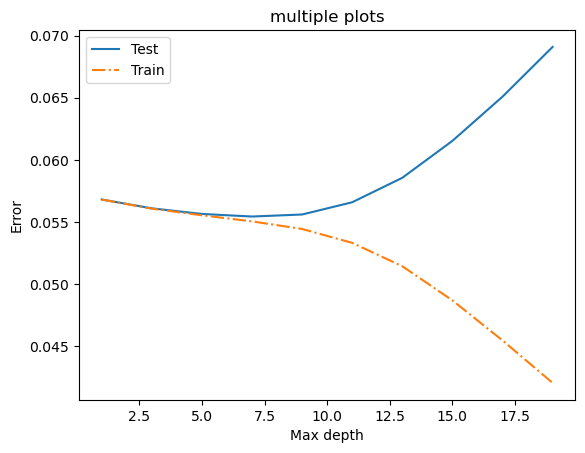

In [33]:
start_value = 1
end_value = 20
index = 2
x_graph = list(range(start_value, end_value,index))
y_graph_test = []
y_graph_train = []

X2 = np.array(df_clean[moost_important_features])

for parameter in range(start_value,end_value,index):
    model = CustomDecisionTreeRegressor(max_depth=parameter, min_samples_leafs=10)

    fold_test = []
    fold_train = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X = X2,y=y_class)):
        print(f"Doing fold {fold}")
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train,y_train)
    
        y_pred_test = model.predict(X_val)
        y_pred_train = model.predict(X_train)

        fold_test.append(mean_squared_error(y_pred=y_pred_test, y_true=y_val))
        fold_train.append(mean_squared_error(y_pred=y_pred_train, y_true=y_train))


    train_score = np.mean(fold_train)
    test_score = np.mean(fold_test)


    y_graph_test.append(test_score)
    y_graph_train.append(train_score)

plt.plot(x_graph, y_graph_test, label ='Test')
plt.plot(x_graph, y_graph_train, '-.', label ='Train')

plt.xlabel("Max depth")
plt.ylabel("Error")
plt.legend()
plt.title('multiple plots')
plt.show()

# Minimum number of samples in leaf 5

Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4


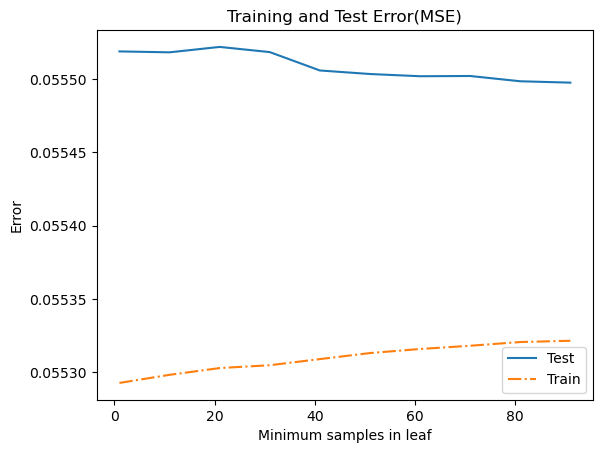

In [34]:
start_value = 1
end_value = 101
index = 10
x_graph = list(range(start_value, end_value,index))
y_graph_test = []
y_graph_train = []

X2 = np.array(df_clean[moost_important_features])

for parameter in range(start_value,end_value,index):
    model = CustomDecisionTreeRegressor(max_depth=6, min_samples_leafs=parameter)

    fold_test = []
    fold_train = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X = X2,y=y_class)):
        print(f"Doing fold {fold}")
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train,y_train)
    
        y_pred_test = model.predict(X_val)
        y_pred_train = model.predict(X_train)

        fold_test.append(mean_squared_error(y_pred=y_pred_test, y_true=y_val))
        fold_train.append(mean_squared_error(y_pred=y_pred_train, y_true=y_train))


    train_score = np.mean(fold_train)
    test_score = np.mean(fold_test)


    y_graph_test.append(test_score)
    y_graph_train.append(train_score)

plt.plot(x_graph, y_graph_test, label ='Test')
plt.plot(x_graph, y_graph_train, '-.', label ='Train')

plt.xlabel("Minimum samples in leaf")
plt.ylabel("Error")
plt.legend()
plt.title('Training and Test Error(MSE)')
plt.show()

# Minimum number of samples in leaf 5

Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4
Doing fold 0
Doing fold 1
Doing fold 2
Doing fold 3
Doing fold 4


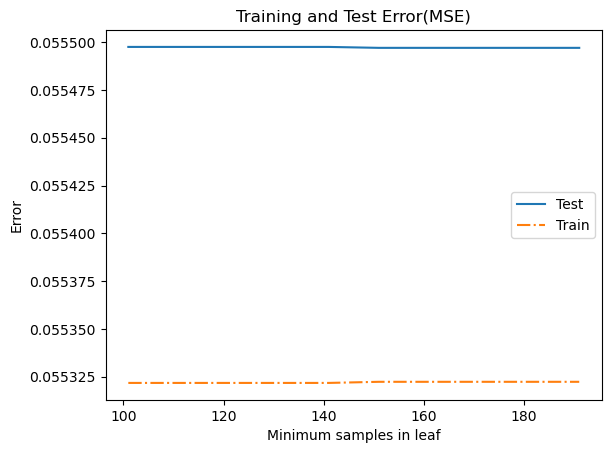

In [35]:
start_value = 101
end_value = 201
index = 10
x_graph = list(range(start_value, end_value,index))
y_graph_test = []
y_graph_train = []

X2 = np.array(df_clean[moost_important_features])

for parameter in range(start_value,end_value,index):
    model = CustomDecisionTreeRegressor(max_depth=6, min_samples_leafs=parameter)

    fold_test = []
    fold_train = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X = X2,y=y_class)):
        print(f"Doing fold {fold}")
        X_train, X_val = X2[train_idx], X2[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train,y_train)
    
        y_pred_test = model.predict(X_val)
        y_pred_train = model.predict(X_train)

        fold_test.append(mean_squared_error(y_pred=y_pred_test, y_true=y_val))
        fold_train.append(mean_squared_error(y_pred=y_pred_train, y_true=y_train))


    train_score = np.mean(fold_train)
    test_score = np.mean(fold_test)


    y_graph_test.append(test_score)
    y_graph_train.append(train_score)

plt.plot(x_graph, y_graph_test, label ='Test')
plt.plot(x_graph, y_graph_train, '-.', label ='Train')

plt.xlabel("Minimum samples in leaf")
plt.ylabel("Error")
plt.legend()
plt.title('Training and Test Error(MSE)')
plt.show()

# Minimum number of samples in leaf 5